In [2]:
import ba
import numpy as np
import random
import matplotlib.pyplot as plt
import copy

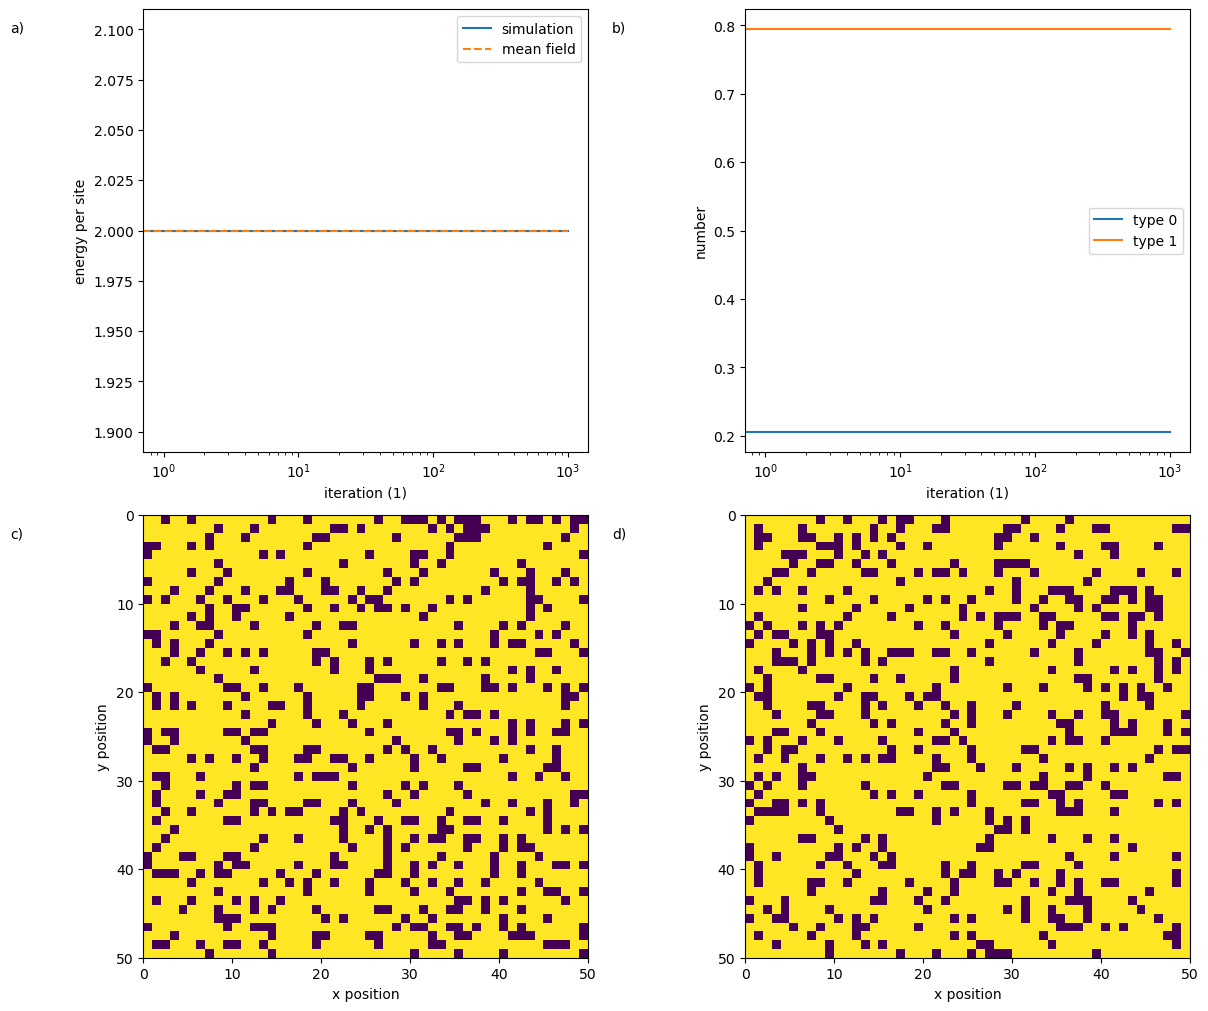

In [35]:
#
# Set number of site changes and frequency of recording simulation variables
#
iterationNumber=1000
outputFreq=1
#
# Initialize system (50*50 lattice)
#
mySystem=ba.baClass(Nx=50,Ny=50,J00=1.0,J11=1.0,J01=1.0,concentration=0.2)
#
# Record the initial state for later visualization
#
initialState=copy.deepcopy(mySystem.latticeState)
#
# Calculate initial total energy 
#
currentEnergy=mySystem.calcEnergy()
#
# Initialize lists which record simulation evolution
#
iterationEvolution=[]
energyEvolution=[]
meanFieldEnergyEvolution=[]
N0Evolution=[]
N1Evolution=[]
#
# Add starting state to list
#
iterationEvolution.append(0)
energyEvolution.append(currentEnergy/float(mySystem.siteNumber))
x0=float(mySystem.type0SiteNumber)/float(mySystem.siteNumber)
x1=float(mySystem.type1SiteNumber)/float(mySystem.siteNumber)
N0Evolution.append(x0)
N1Evolution.append(x1)
meanFieldEnergyEvolution.append(0.5*mySystem.J00*4.0*x0+0.5*mySystem.J11*4.0*x1+4.0*x0*x1*(mySystem.J01-0.5*(mySystem.J00+mySystem.J11)))
#
# Randomly change the state of the site, accept the change only if the energy drops
#
for i in range(iterationNumber):
    #
    # Randomly choose the x and y coordinates of two sites of differeing type
    #
    ix1=np.random.randint(mySystem.Nx)
    iy1=np.random.randint(mySystem.Ny)
    type1=mySystem.latticeState[ix1,iy1]
    type2=type1
    while (type2==type1):
        ix2=np.random.randint(mySystem.Nx)
        iy2=np.random.randint(mySystem.Ny)
        type2=mySystem.latticeState[ix2,iy2]
    #
    # Change the chosen site's state, calculate the change in eneryy
    #
    deltaEnergy=mySystem.changeSiteState(ix1,iy1)
    deltaEnergy+=mySystem.changeSiteState(ix2,iy2)
    if (deltaEnergy>0.0):
        #
        # Undo the change if the exchange is not accepted
        #
        mySystem.changeSiteState(ix1,iy1,calcDeltaEnergy=False)
        mySystem.changeSiteState(ix2,iy2,calcDeltaEnergy=False)

    else:
        #
        # If the energy decreases update the current total energy
        #
        currentEnergy+=deltaEnergy
    #
    # Record system variables for later plotting
    #
    if (i%outputFreq==0):
        iterationEvolution.append(i/outputFreq)
        energyEvolution.append(currentEnergy/float(mySystem.siteNumber))
        N0Evolution.append(float(mySystem.type0SiteNumber)/float(mySystem.siteNumber))
        N1Evolution.append(float(mySystem.type1SiteNumber)/float(mySystem.siteNumber))
        meanFieldEnergyEvolution.append(0.5*mySystem.J00*4.0*x0+0.5*mySystem.J11*4.0*x1+4.0*x0*x1*(mySystem.J01-0.5*(mySystem.J00+mySystem.J11)))

#
# Define subplot arrangement
#
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2,2)
panel00 = fig.add_subplot(gs[0,0])
panel01 = fig.add_subplot(gs[0,1])
panel10 = fig.add_subplot(gs[1,0])
panel11 = fig.add_subplot(gs[1,1])
#
# Plot the corresponding energy evolution
#
panel00.set_xlabel(r'iteration ('+str(outputFreq)+')')
panel00.set_ylabel(r'energy per site')
panel00.set_xscale('log')
panel00.plot(iterationEvolution,energyEvolution,label='simulation')
panel00.plot(iterationEvolution,meanFieldEnergyEvolution,linestyle='dashed',label='mean field')
handles, labels = panel00.get_legend_handles_labels()
panel00.legend(handles, labels)
panel00.text(-0.3,0.95,'a)',transform=panel00.transAxes)
#
# Plot the populations of type 0 and type 1
#
panel01.set_xlabel(r'iteration ('+str(outputFreq)+')')
panel01.set_ylabel(r'number')
panel01.set_xscale('log')
panel01.plot(iterationEvolution,N0Evolution,label='type 0')
panel01.plot(iterationEvolution,N1Evolution,label='type 1')
handles, labels = panel01.get_legend_handles_labels()
panel01.legend(handles, labels)
panel01.text(-0.3,0.95,'b)',transform=panel01.transAxes)
#
# Visualize the initial configuration
#
panel10.set_xlabel(r'x position')
panel10.set_ylabel(r'y position')
panel10.matshow(initialState,extent=(0,mySystem.Nx,mySystem.Ny,0),aspect="auto",vmin=0,vmax=1)
panel10.xaxis.set_ticks_position('bottom')
panel10.text(-0.3,0.95,'c)',transform=panel10.transAxes)
#
# Visualize the final configuration
#
panel11.set_xlabel(r'x position')
panel11.set_ylabel(r'y position')
panel11.matshow(mySystem.latticeState,extent=(0,mySystem.Nx,mySystem.Ny,0),aspect="auto",vmin=0,vmax=1)
panel11.xaxis.set_ticks_position('bottom')
panel11.text(-0.3,0.95,'d)',transform=panel11.transAxes)
#
# Set figure size and plot
#
fig.set_figheight(10)
fig.set_figwidth(12)
plt.show()
fig.savefig('energyMinimizationExchange.png') 